In [42]:
# ---- IMPORTS -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [43]:
# ---- LOAD DATA ----

df = pd.read_csv("clean_events.csv")
features_master = pd.read_csv("features_master.csv")

# Quick check
print("Events shape        :", df.shape)
print("Features shape      :", features_master.shape)

print("\nEvent types:")
print(df['event_type'].value_counts())

Events shape        : (2755641, 12)
Features shape      : (1407580, 29)

Event types:
event_type
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


In [44]:
# --- Fix Data Types ---

# Parse mixed datetime formats and strip timezone if present
df['event_datetime'] = pd.to_datetime(df['event_datetime'], format='mixed')
if df['event_datetime'].dt.tz:
    df['event_datetime'] = df['event_datetime'].dt.tz_convert(None)

# IDs should be strings — avoids accidental numeric operations
for col in ['visitorid', 'session_id', 'itemid']:
    df[col] = df[col].astype(str)

print(df.dtypes)

visitorid                    str
session_id                   str
session_num                int64
event_type                   str
itemid                       str
transactionid            float64
event_datetime    datetime64[us]
hour_of_day                int64
day_of_week                int64
is_weekend                 int64
categoryid                 int64
available                  int64
dtype: object


In [45]:
# --- SECTION 1: BASIC PROBABILITIES ---

# --- Basic User Behavior Probabilities ---

# Total users
total_users = len(features_master)
# Buyer-related counts
buyers = features_master['has_purchased'].sum()
cart_users = features_master['has_cart'].sum()
# View only users
view_only_users = ((features_master['has_purchased'] == 0) & (features_master['has_cart'] == 0)).sum()
# Cart abandoners
cart_no_purchase = features_master['cart_without_purchase'].sum()
# Return visitors
return_visitors = features_master['return_visitor'].sum()
# --- Probability Calculations ---
p_purchase = buyers / total_users
p_cart = cart_users / total_users
p_view_only = view_only_users / total_users
p_cart_no_buy = cart_no_purchase / total_users
p_return_visit = return_visitors / total_users

# --- Output ---

print("=" * 50)
print("BASIC PROBABILITIES")
print("=" * 50)

print(f"Total Users               : {total_users:,}")
print(f"\nP(Purchase)               : {p_purchase:.4f} ({p_purchase*100:.2f}%)")
print(f"P(AddToCart)              : {p_cart:.4f} ({p_cart*100:.2f}%)")
print(f"P(View Only, No Cart)     : {p_view_only:.4f} ({p_view_only*100:.2f}%)")
print(f"P(Cart but No Purchase)   : {p_cart_no_buy:.4f} ({p_cart_no_buy*100:.2f}%)")
print(f"P(Return Visit)           : {p_return_visit:.4f} ({p_return_visit*100:.2f}%)")

BASIC PROBABILITIES
Total Users               : 1,407,580

P(Purchase)               : 0.0083 (0.83%)
P(AddToCart)              : 0.0268 (2.68%)
P(View Only, No Cart)     : 0.9724 (97.24%)
P(Cart but No Purchase)   : 0.0193 (1.93%)
P(Return Visit)           : 0.1290 (12.90%)


In [46]:
# --- SECTION 2: CONDITIONAL PROBABILITIES ---

# --- Conditional Probability Calculations ---

# Users who added to cart
cart_users_df = features_master[features_master['has_cart'] == 1]
# P(Purchase | AddToCart)
p_buy_given_cart = cart_users_df['has_purchased'].mean()
# P(Purchase | View)
p_buy_given_view = features_master['has_purchased'].mean()
# Users with 3+ views
heavy_viewers = features_master[features_master['total_views'] >= 3]
# P(Purchase | 3+ Views)
p_buy_given_3views = heavy_viewers['has_purchased'].mean()
# Weekend users
weekend_users = features_master[features_master['is_weekend_user'] == 1]
# P(Purchase | Weekend)
p_buy_given_weekend = weekend_users['has_purchased'].mean()
# P(Cart | View)
p_cart_given_view = features_master['has_cart'].mean()
# P(Abandon | Cart)
p_abandon_given_cart = (cart_users_df['cart_without_purchase'].mean())

# --- Output ---

print("=" * 50)
print("CONDITIONAL PROBABILITIES")
print("=" * 50)

print(f"P(Purchase | Has Cart)    : {p_buy_given_cart:.4f} ({p_buy_given_cart*100:.2f}%)")
print(f"P(Purchase | View)        : {p_buy_given_view:.4f} ({p_buy_given_view*100:.2f}%)")
print(f"P(Purchase | 3+ Views)    : {p_buy_given_3views:.4f} ({p_buy_given_3views*100:.2f}%)")
print(f"P(Purchase | Weekend)     : {p_buy_given_weekend:.4f} ({p_buy_given_weekend*100:.2f}%)")
print(f"P(Cart | View)            : {p_cart_given_view:.4f} ({p_cart_given_view*100:.2f}%)")
print(f"P(Abandon | Cart)         : {p_abandon_given_cart:.4f} ({p_abandon_given_cart*100:.2f}%)")

CONDITIONAL PROBABILITIES
P(Purchase | Has Cart)    : 0.2804 (28.04%)
P(Purchase | View)        : 0.0083 (0.83%)
P(Purchase | 3+ Views)    : 0.0386 (3.86%)
P(Purchase | Weekend)     : 0.0062 (0.62%)
P(Cart | View)            : 0.0268 (2.68%)
P(Abandon | Cart)         : 0.7196 (71.96%)


In [47]:
# --- SECTION 3: BAYES THEOREM ---

# --- Setup threshold ---
heavy_viewer_threshold = 5

# --- Probabilities ---

# P(Heavy Viewer)
p_heavy_viewer = (features_master['total_views'] >= heavy_viewer_threshold).mean()
# P(Buyer)
p_buyer = features_master['has_purchased'].mean()
# Users who bought
buyers_df = features_master[features_master['has_purchased'] == 1]
# P(Heavy Viewer | Buyer)
p_heavy_viewer_given_buy = (buyers_df['total_views'] >= heavy_viewer_threshold).mean()
# --- Bayes Theorem ---
p_buyer_given_heavy = (p_heavy_viewer_given_buy * p_buyer /p_heavy_viewer)

# --- Output ---

print("=" * 50)
print("BAYES THEOREM")
print("=" * 50)

print(f"\nHeavy Viewer = viewed {heavy_viewer_threshold}+ items")
print(f"\nP(Heavy Viewer)              : {p_heavy_viewer:.4f} ({p_heavy_viewer*100:.2f}%)")
print(f"P(Buyer)                     : {p_buyer:.4f} ({p_buyer*100:.2f}%)")
print(f"P(Heavy Viewer | Buyer)      : {p_heavy_viewer_given_buy:.4f} ({p_heavy_viewer_given_buy*100:.2f}%)")
print(f"P(Buyer | Heavy Viewer)      : {p_buyer_given_heavy:.4f} ({p_buyer_given_heavy*100:.2f}%)")

# --- Business Insight ---
print("\nBusiness Insight:")
if p_buyer > 0:
    lift = p_buyer_given_heavy / p_buyer
    print(f"A heavy viewer is {lift:.1f}x more likely to buy than an average user")
else:
    print("Insufficient data for lift calculation")

BAYES THEOREM

Heavy Viewer = viewed 5+ items

P(Heavy Viewer)              : 0.0541 (5.41%)
P(Buyer)                     : 0.0083 (0.83%)
P(Heavy Viewer | Buyer)      : 0.4380 (43.80%)
P(Buyer | Heavy Viewer)      : 0.0674 (6.74%)

Business Insight:
A heavy viewer is 8.1x more likely to buy than an average user


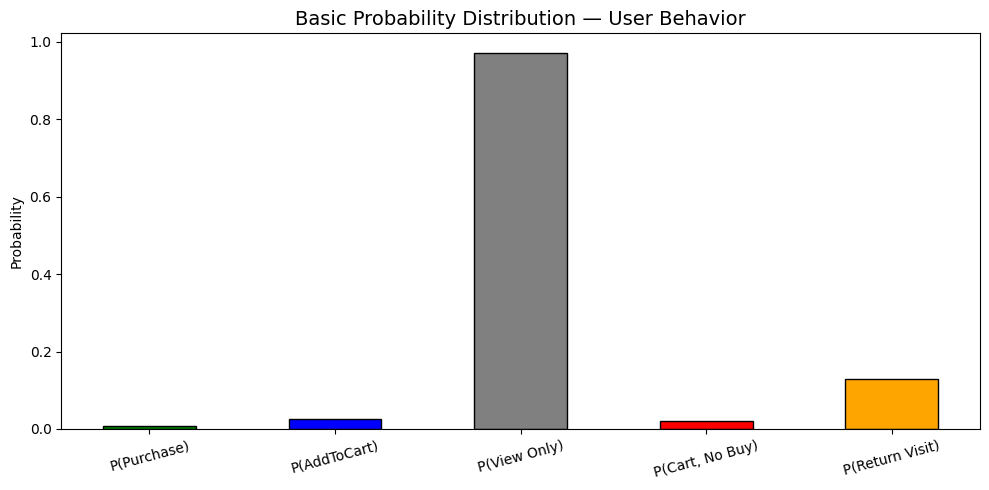

In [48]:
# ---  SECTION 5: VISUALIZATIONS---

import matplotlib.pyplot as plt

# --- Labels ---
labels = [
    'P(Purchase)',
    'P(AddToCart)',
    'P(View Only)',
    'P(Cart, No Buy)',
    'P(Return Visit)'
]

# --- Values ---
values = [
    p_purchase,
    p_cart,
    p_view_only,
    p_cart_no_buy,
    p_return_visit
]

# --- Colors ---
colors = ['green', 'blue', 'gray', 'red', 'orange']

# --- Plot ---
plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.5)

# --- Styling ---
plt.title('Basic Probability Distribution — User Behavior', fontsize=14)
plt.ylabel('Probability')
plt.xticks(rotation=15)
plt.ylim(0, max(values) + 0.05)

plt.tight_layout()

# --- Save + Show ---
plt.savefig('basic_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

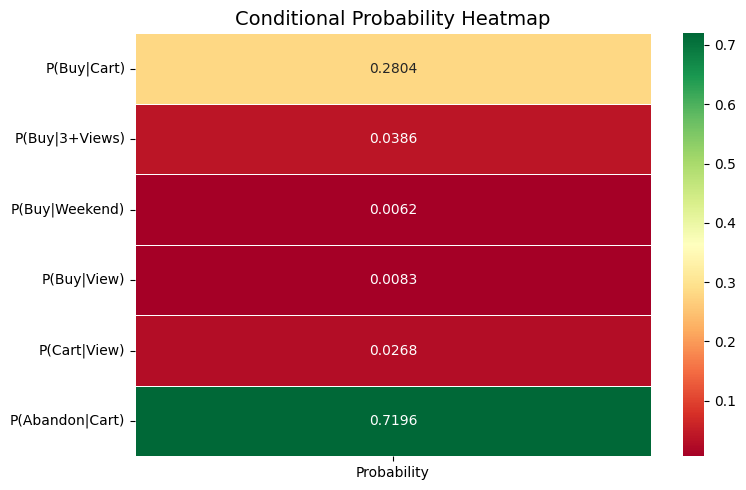

In [49]:
# ---- SECTION 6: CONDITIONAL PROBABILITY HEATMAP ----

# --- Import Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Conditional Probability Dictionary ---
cond_probs = {
    'P(Buy|Cart)': p_buy_given_cart,
    'P(Buy|3+Views)': p_buy_given_3views,
    'P(Buy|Weekend)': p_buy_given_weekend,
    'P(Buy|View)': p_buy_given_view,
    'P(Cart|View)': p_cart_given_view,
    'P(Abandon|Cart)': p_abandon_given_cart
}

# --- Create DataFrame for Heatmap ---
cond_df = pd.DataFrame(
    list(cond_probs.values()),
    index=list(cond_probs.keys()),
    columns=['Probability'])

# --- Figure Setup ---
plt.figure(figsize=(8, 5))

# --- Heatmap Creation ---
sns.heatmap(
    cond_df,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar=True)

# --- Chart Title ---
plt.title('Conditional Probability Heatmap', fontsize=14)
# --- Layout Adjustment ---
plt.tight_layout()
# --- Save Figure ---
plt.savefig('conditional_probability_heatmap.png', dpi=150)
# --- Show Plot ---
plt.show()

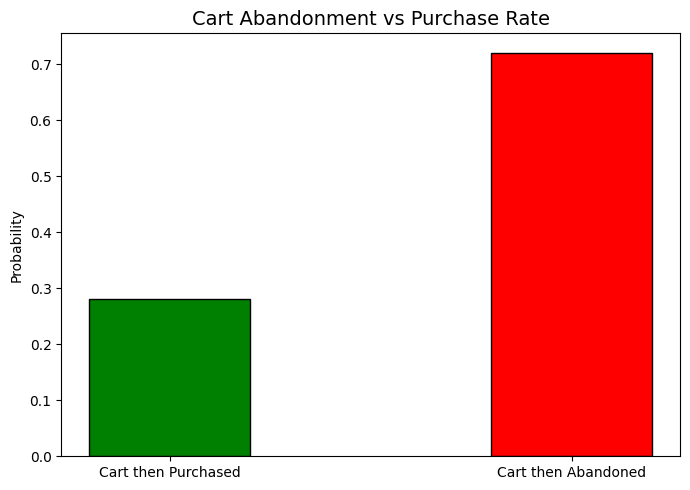

In [50]:
# --- SECTION 7: CART ABANDONMENT VISUALIZATION -----

# --- Abandonment Probability Highlight ---

# --- Labels ---
labels = ['Cart then Purchased', 'Cart then Abandoned']
# --- Values ---
values = [p_buy_given_cart, p_abandon_given_cart]
# --- Colors ---
colors = ['green', 'red']
# --- Figure Setup ---
plt.figure(figsize=(7, 5))
# --- Create Bar Chart ---
bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.4)

# --- Chart Title ---
plt.title('Cart Abandonment vs Purchase Rate', fontsize=14)
# --- Axis Label ---
plt.ylabel('Probability')
# --- Layout Adjustment ---
plt.tight_layout()
# --- Save Figure ---
plt.savefig('cart_abandonment_highlight.png', dpi=150)
# --- Show Plot ---
plt.show()

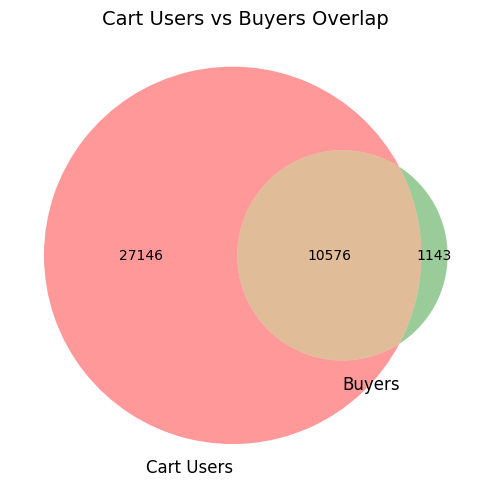

In [51]:
# ---- SECTION 8: USER OVERLAP (VENN DIAGRAM)----

# --- Import Libraries ---
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# --- Cart Users Set ---
cart_set = set(features_master.loc[features_master['has_cart'] == 1,'visitorid'])
# --- Buyer Users Set ---
buyer_set = set(features_master.loc[features_master['has_purchased'] == 1,'visitorid'])
# --- Figure Setup ---
plt.figure(figsize=(7, 5))

# --- Venn Diagram ---
venn2([cart_set, buyer_set],set_labels=('Cart Users', 'Buyers'))
# --- Chart Title ---
plt.title('Cart Users vs Buyers Overlap', fontsize=14)
# --- Layout Adjustment ---
plt.tight_layout()
# --- Save Figure ---
plt.savefig('venn_diagram.png', dpi=150)

# --- Show Plot ---
plt.show()

In [52]:
# ============================================================
# SECTION 9: EXPORT RESULTS
# ============================================================

# --- Create Probability Results Table ---

prob_results = pd.DataFrame({
    'metric': [
        'P(Purchase)',
        'P(AddToCart)',
        'P(View Only)',
        'P(Cart but No Purchase)',
        'P(Return Visit)',
        'P(Purchase | Cart)',
        'P(Purchase | View)',
        'P(Purchase | 3+ Views)',
        'P(Purchase | Weekend)',
        'P(Cart | View)',
        'P(Abandon | Cart)',
        'P(Heavy Viewer)',
        'P(Buyer | Heavy Viewer)',
        'P(View AND Purchase)',
        'P(Cart AND No Purchase)',
        'P(Return AND Purchase)'
    ],
    'probability': [
        p_purchase,
        p_cart,
        p_view_only,
        p_cart_no_buy,
        p_return_visit,
        p_buy_given_cart,
        p_buy_given_view,
        p_buy_given_3views,
        p_buy_given_weekend,
        p_cart_given_view,
        p_abandon_given_cart,
        p_heavy_viewer,
        p_buyer_given_heavy,
        p_view_and_purchase,
        p_cart_and_no_purchase,
        p_return_and_purchase
    ]
})

# --- Add Percentage Column ---
prob_results['probability_pct'] = (prob_results['probability'] * 100).round(4)
# --- Save CSV File ---
prob_results.to_csv("probability_results.csv", index=False)

# --- Output ---
print("probability_results.csv →", len(prob_results), "metrics")
print(prob_results)

probability_results.csv → 16 metrics
                     metric  probability  probability_pct
0               P(Purchase)     0.008326           0.8326
1              P(AddToCart)     0.026799           2.6799
2              P(View Only)     0.972389          97.2389
3   P(Cart but No Purchase)     0.019286           1.9286
4           P(Return Visit)     0.129039          12.9039
5        P(Purchase | Cart)     0.280367          28.0367
6        P(Purchase | View)     0.008326           0.8326
7    P(Purchase | 3+ Views)     0.038585           3.8585
8     P(Purchase | Weekend)     0.006154           0.6154
9            P(Cart | View)     0.026799           2.6799
10        P(Abandon | Cart)     0.719633          71.9633
11          P(Heavy Viewer)     0.054114           5.4114
12  P(Buyer | Heavy Viewer)     0.067389           6.7389
13     P(View AND Purchase)     0.008022           0.8022
14  P(Cart AND No Purchase)     0.019286           1.9286
15   P(Return AND Purchase)     0.0